#### **Petróleo × PETR4 × PRIO3 (2020–2026)**

**Hipótese.** Se o governo segura o preço dos combustíveis para conter a inflação, a Petrobras
(PETR4, integrada, com refino) não repassa a alta do petróleo e rende menos que uma produtora
pura (PRIO3) quando o Brent sobe.

Fase 1: só a comparação de mercado. Dados: Yahoo Finance via `yfinance`.

#### **Pergunta de pesquisa**

O mercado precifica a Petrobras como uma empresa de petróleo "cheia" ou como uma empresa
penalizada pelo controle de preços? A comparação com uma produtora pura (PRIO3) isola o efeito
do refino e da política de preços.

#### **Dados e período**

- **Ativos:** `PETR4.SA`, `PRIO3.SA`, `^BVSP` (Ibovespa, controle de mercado).
- **Commodities/câmbio:** `BZ=F` (Brent, USD/barril), `BRL=X` (USD/BRL).
- **Janela:** 2020-01-01 em diante, com `auto_adjust=True` (preços ajustados por proventos).

#### **Método**

1. Normalizar as séries em base 100 para comparar rentabilidades em escalas distintas.
2. Estimar beta e correlação dos log-retornos diários contra o Brent.
3. Acompanhar a correlação rolante (60 dias) e a razão PETR4/PRIO3 ao longo do tempo.
4. Consolidar retorno total, beta e correlação no resumo.

**Critério de decisão.** Se a PETR4 tiver beta e retorno inferiores à PRIO3 na alta do petróleo,
a hipótese de represamento é reforçada.


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
# Coleta de preços de fechamento ajustados (Yahoo Finance) e construção das séries de trabalho.
# auto_adjust=True já corrige splits/proventos; ffill(limit=3) cobre feriados pontuais.
tickers = ["PETR4.SA", "PRIO3.SA", "BZ=F", "BRL=X", "^BVSP"]
df = yf.download(tickers, start="2020-01-01", auto_adjust=True, progress=False)["Close"]
df = df.ffill(limit=3).dropna()
# Brent em R$/barril: converte o petróleo (USD) para a moeda local.
df["Brent_BRL"] = df["BZ=F"] * df["BRL=X"]
df.tail()


Ticker,BRL=X,BZ=F,PETR4.SA,PRIO3.SA,^BVSP,Brent_BRL
Date,,,,,,
2026-09-15,5.1380,108.750000,50.430000,65.680000,186503.0,558.757501
2026-09-16,5.1429,105.830002,48.650002,62.580002,185548.0,544.273115
2026-09-17,5.1509,104.820000,48.650002,62.580002,185992.0,539.917325
2026-09-18,5.1241,103.870003,48.500000,63.240002,185229.0,532.240303
2026-09-21,5.1421,96.559998,48.500000,63.240002,185229.0,496.521150


#### **Séries normalizadas (base 100)**

**Objetivo.** Comparar a evolução de ativos com preços em ordens de grandeza muito diferentes
(ação em R$, Brent em R$/barril, índice em pontos). A normalização em base 100 fixa o primeiro
pregão em 100 e mostra o retorno acumulado relativo.

**Leitura esperada.** Se a PRIO3 subir mais que a PETR4 no período de alta do petróleo, a tese
ganha suporte visual.


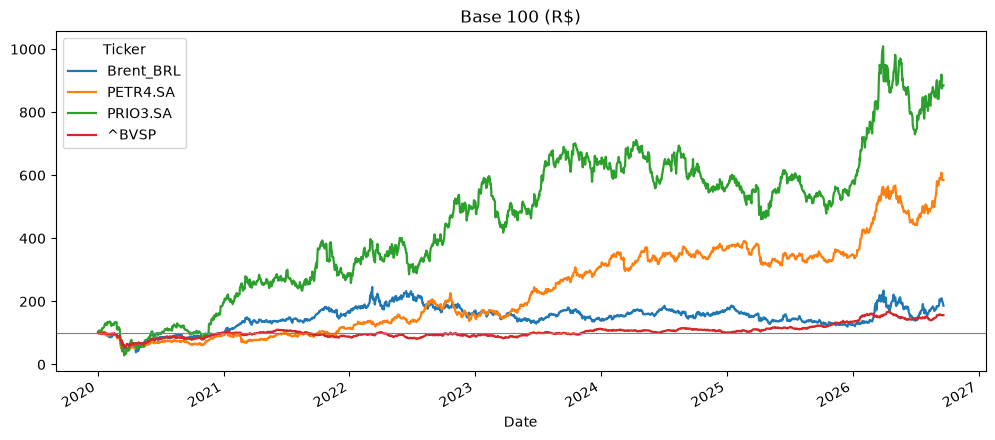

In [3]:
# Normaliza cada série pelo seu primeiro valor (base 100) para comparar rentabilidade relativa.
norm = df[["Brent_BRL", "PETR4.SA", "PRIO3.SA", "^BVSP"]] / df[["Brent_BRL", "PETR4.SA", "PRIO3.SA", "^BVSP"]].iloc[0] * 100
norm.plot(title="Base 100 (R$)", lw=1.6)
plt.axhline(100, color="gray", lw=0.8)  # linha de referência = capital inicial
plt.show()


#### **Retorno e sensibilidade ao Brent**

**Objetivo.** Medir a sensibilidade de cada ação ao petróleo. Usamos log-retornos diários
(`Δlog`), que são aproximadamente aditivos e mais estáveis que retornos simples.

- **Beta vs Brent:** covariância do ativo com o Brent / variância do Brent. Beta < 1 = reage menos.
- **Correlação:** força da relação linear no curto prazo.

**Critério de decisão.** Se `beta(PETR4) < beta(PRIO3)`, a empresa integrada captura menos a alta
do petróleo — evidência favorável à hipótese.


In [4]:
# Log-retornos diários: aproximação aditiva e simétrica para retornos pequenos.
ret = np.log(df[["BZ=F", "PETR4.SA", "PRIO3.SA", "^BVSP"]]).diff().dropna()

# Beta e correlação de cada ativo contra o Brent (proxy do petróleo).
res = {}
for col in ["PETR4.SA", "PRIO3.SA", "^BVSP"]:
    beta = np.cov(ret[col], ret["BZ=F"])[0, 1] / np.var(ret["BZ=F"])
    res[col] = {"beta_vs_Brent": beta, "correlacao": ret[col].corr(ret["BZ=F"])}
pd.DataFrame(res).T.round(3)


,beta_vs_Brent,correlacao
PETR4.SA,0.389,0.425
PRIO3.SA,0.595,0.469
^BVSP,0.110,0.208


#### **Correlação rolante (60 dias) com o Brent**

**Objetivo.** A correlação estática esconde mudanças de regime. A janela de 60 dias (~3 meses de
pregões) suaviza o ruído diário sem apagar as mudanças de política de preços.

**Leitura esperada.** Quedas da correlação da PETR4 em períodos de intervenção sugerem desconexão
do preço internacional.


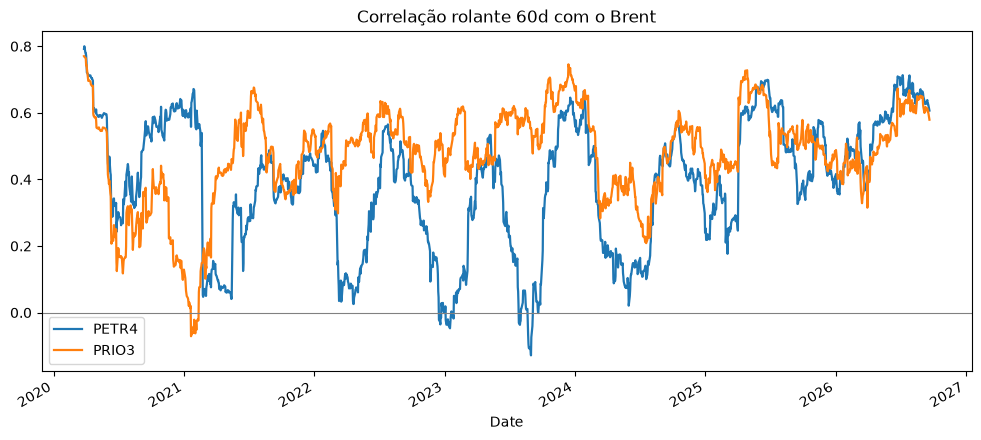

In [5]:
# Correlação rolante de 60 dias (~3 meses) para capturar mudanças de regime.
rc = pd.DataFrame({
    "PETR4": ret["PETR4.SA"].rolling(60).corr(ret["BZ=F"]),
    "PRIO3": ret["PRIO3.SA"].rolling(60).corr(ret["BZ=F"]),
})
rc.plot(title="Correlação rolante 60d com o Brent", lw=1.6)
plt.axhline(0, color="gray", lw=0.8)  # zero = sem relação linear
plt.show()


#### **Razão PETR4 / PRIO3**

**Objetivo.** Isolar o desempenho relativo das duas empresas, removendo o efeito do mercado.
Uma razão normalizada em base 100 que cai indica perda de valor relativo da Petrobras.

**Leitura esperada.** Se a razão cai justamente nos períodos de alta do petróleo, reforça a tese
de que a PETR4 não repassa a alta.


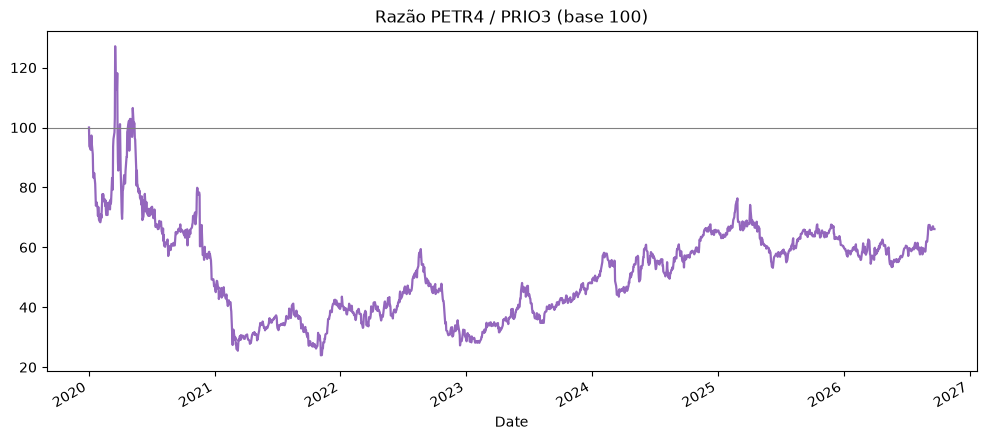

In [6]:
# Razão entre os preços, normalizada em base 100 (relativo ao início da série).
razao = df["PETR4.SA"] / df["PRIO3.SA"]
(razao / razao.iloc[0] * 100).plot(title="Razão PETR4 / PRIO3 (base 100)", color="C4", lw=1.6)
plt.axhline(100, color="gray", lw=0.8)
plt.show()


#### **Brent em R$ vs PETR4**

**Objetivo.** Ver simultaneamente o insumo (Brent em R$/barril) e as ações, em eixos separados
por causa das unidades distintas. Eixos gêmeos permitem comparar a tendência, não o nível.

**Leitura esperada.** Divergência entre Brent e PETR4 (Brent sobe, ação não acompanha) aponta
para represamento ou desconto de risco político.


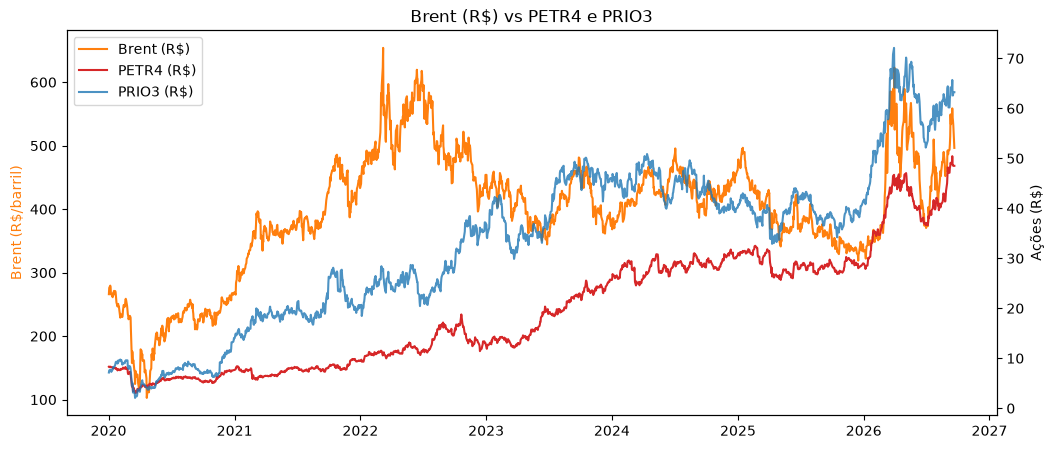

In [7]:
# Dois eixos y: Brent em R$/barril (esquerda) e ações em R$ (direita).
fig, ax1 = plt.subplots()
ax1.plot(df.index, df["Brent_BRL"], color="C1", label="Brent (R$)")
ax1.set_ylabel("Brent (R$/barril)", color="C1")
ax2 = ax1.twinx()
ax2.plot(df.index, df["PETR4.SA"], color="C3", label="PETR4 (R$)")
ax2.plot(df.index, df["PRIO3.SA"], color="C0", label="PRIO3 (R$)", alpha=0.8)
ax2.set_ylabel("Ações (R$)")
ax2.grid(False)  # evita grade duplicada sobre o eixo da esquerda
# Une as legendas dos dois eixos em uma única caixa.
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")
plt.title("Brent (R$) vs PETR4 e PRIO3")
plt.show()


#### **Resumo**

**Objetivo.** Consolidar, em uma única saída, período, retorno total de cada ativo, razão
PETR4/PRIO3 e os parâmetros de sensibilidade (beta e correlação) estimados acima.


In [8]:
# Consolida os indicadores da Fase 1 em um bloco de texto para o resumo.
print(f"Período: {df.index.min().date()} a {df.index.max().date()} ({len(df)} pregões)")
for t in ["PETR4.SA", "PRIO3.SA", "Brent_BRL", "^BVSP"]:
    print(f"  {t:10s} retorno total: {(df[t].iloc[-1]/df[t].iloc[0]-1)*100:+6.1f}%")
print(f"  Razão PETR4/PRIO3: {(razao.iloc[-1]/razao.iloc[0]-1)*100:+.1f}%")
# Recupera beta/correlação da tabela montada na célula de sensibilidade.
t = pd.DataFrame(res).T
print(f"  beta PETR4={t.loc['PETR4.SA','beta_vs_Brent']:.2f}  PRIO3={t.loc['PRIO3.SA','beta_vs_Brent']:.2f}"
      f"  |  corr PETR4={t.loc['PETR4.SA','correlacao']:.2f}  PRIO3={t.loc['PRIO3.SA','correlacao']:.2f}")


Período: 2020-01-02 a 2026-09-21 (1749 pregões)
  PETR4.SA   retorno total: +485.1%
  PRIO3.SA   retorno total: +785.2%
  Brent_BRL  retorno total:  +86.6%
  ^BVSP      retorno total:  +56.2%
  Razão PETR4/PRIO3: -33.9%
  beta PETR4=0.39  PRIO3=0.60  |  corr PETR4=0.43  PRIO3=0.47


#### **Conclusão (Fase 1)**

A hipótese é reforçada no mercado: a PETR4 tem beta ao Brent de 0,39 contra 0,60 da PRIO3, e
retorno total menor (+485% vs +785% no período). A leitura é que a empresa integrada não repassa
toda a alta do petróleo, consistente com controle de preços dos combustíveis. A evidência de
repasse e de gap de paridade está em `02_combustivel.ipynb`.
